<a href="https://colab.research.google.com/github/ridhimasharma1108/ml-project/blob/main/Quikr_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

%matplotlib inline
plt.style.use('ggplot')


In [7]:
!pip install gdown

import gdown

# replace FILE_ID with your Google Drive file id
file_id = "17wcOi_UoPklpR2R2a2OPv9RjOvCnLxWj"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, 'quikr_car.csv', quiet=False)

car = pd.read_csv('quikr_car.csv')

Downloading...
From: https://drive.google.com/uc?id=17wcOi_UoPklpR2R2a2OPv9RjOvCnLxWj
To: /content/quikr_car.csv
100%|██████████| 60.1k/60.1k [00:00<00:00, 46.6MB/s]


In [8]:
car.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [9]:
car.shape

(892, 6)

In [10]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


##### Creating backup copy

In [11]:
# Backup copy
car_backup = car.copy()

# Check backup shape
car_backup.shape


(892, 6)

## Quality

- names are pretty inconsistent
- names have company names attached to it
- some names are spam like 'Maruti Ertiga showroom condition with' and 'Well mentained Tata Sumo'
- company: many of the names are not of any company like 'Used', 'URJENT', and so on.
- year has many non-year values
- year is in object. Change to integer
- Price has Ask for Price
- Price has commas in its prices and is in object
- kms_driven has object values with kms at last.
- It has nan values and two rows have 'Petrol' in them
- fuel_type has nan values

## Cleaning Data

#### year has many non-year values

In [13]:

car = car[car['year'].str.isnumeric()]
car['year'] = car['year'].astype(int)



#### year is in object. Change to integer

In [14]:
car['year']=car['year'].astype(int)
print(car['year'].dtype)
car.head()

int64


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


#### Price has Ask for Price

In [15]:
car = car[car['Price'] != 'Ask For Price']
car['Price'] = car['Price'].str.replace('₹', '', regex=True)
car['Price'] = car['Price'].str.replace(',', '', regex=True)
car['Price'] = car['Price'].astype(int)

print(car['Price'].dtype)
car['Price'].head()


int64


,Price
0,80000
1,425000
3,325000
4,575000
6,175000


#### Price has commas in its prices and is in object

In [18]:
car = car[car['Price'] != 'Ask For Price']
car['Price'] = car['Price'].astype(str)
car['Price'] = car['Price'].str.replace('₹', '', regex=True)
car['Price'] = car['Price'].str.replace(',', '', regex=True)
car['Price'] = car['Price'].astype(int)
print(car['Price'].dtype)
car['Price'].head()


int64


,Price
0,80000
1,425000
3,325000
4,575000
6,175000


####  kms_driven has object values with kms at last.

In [70]:
car['kms_driven'] = car['kms_driven'].astype(str)
car['kms_driven'] = car['kms_driven'].str.replace('kms', '', regex=True)
car['kms_driven'] = car['kms_driven'].str.replace(',', '', regex=True)
car['kms_driven'] = pd.to_numeric(car['kms_driven'], errors='coerce')


#### It has nan values and two rows have 'Petrol' in them

In [68]:
car['kms_driven'] = car['kms_driven'].astype(str) \
                                     .str.replace('kms', '', regex=True) \
                                     .str.replace(',', '', regex=True)

car['kms_driven'] = pd.to_numeric(car['kms_driven'], errors='coerce')  # non-numeric → NaN


car['kms_driven'] = car['kms_driven'].astype(int)


In [69]:
car['kms_driven']=car['kms_driven'].astype(int)
print(car['kms_driven'].dtype)
car['kms_driven'].head()

int64


,kms_driven


#### fuel_type has nan values

In [67]:
print(car['fuel_type'].isna().sum())
print(car['fuel_type'].unique())


0
[]


In [22]:
car.shape

(0, 6)

### name and company had spammed data...but with the previous cleaning, those rows got removed.

#### Company does not need any cleaning now. Changing car names. Keeping only the first three words

In [23]:
car['name'] = car['name'].apply(lambda x: ' '.join(x.split()[:3]))

car['name'].head(10)


,name


#### Resetting the index of the final cleaned data

In [24]:
car = car.reset_index(drop=True)
car.head()
car.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        0 non-null      object
 1   company     0 non-null      object
 2   year        0 non-null      int64 
 3   Price       0 non-null      int64 
 4   kms_driven  0 non-null      int64 
 5   fuel_type   0 non-null      object
dtypes: int64(3), object(3)
memory usage: 132.0+ bytes


## Cleaned Data

In [25]:
car

,name,company,year,Price,kms_driven,fuel_type


In [26]:
car.to_csv('Cleaned_Car_data.csv')

In [27]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        0 non-null      object
 1   company     0 non-null      object
 2   year        0 non-null      int64 
 3   Price       0 non-null      int64 
 4   kms_driven  0 non-null      int64 
 5   fuel_type   0 non-null      object
dtypes: int64(3), object(3)
memory usage: 132.0+ bytes


In [28]:
car.describe(include='all')

,name,company,year,Price,kms_driven,fuel_type
count,0,0,0.0,0.0,0.0,0
unique,0,0,NaN,NaN,NaN,0
top,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
car=car[car['Price']<6000000]

### Checking relationship of Company with Price

In [ ]:
car['company'].unique()

In [ ]:
import seaborn as sns

/tmp/ipython-input-2788130517.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


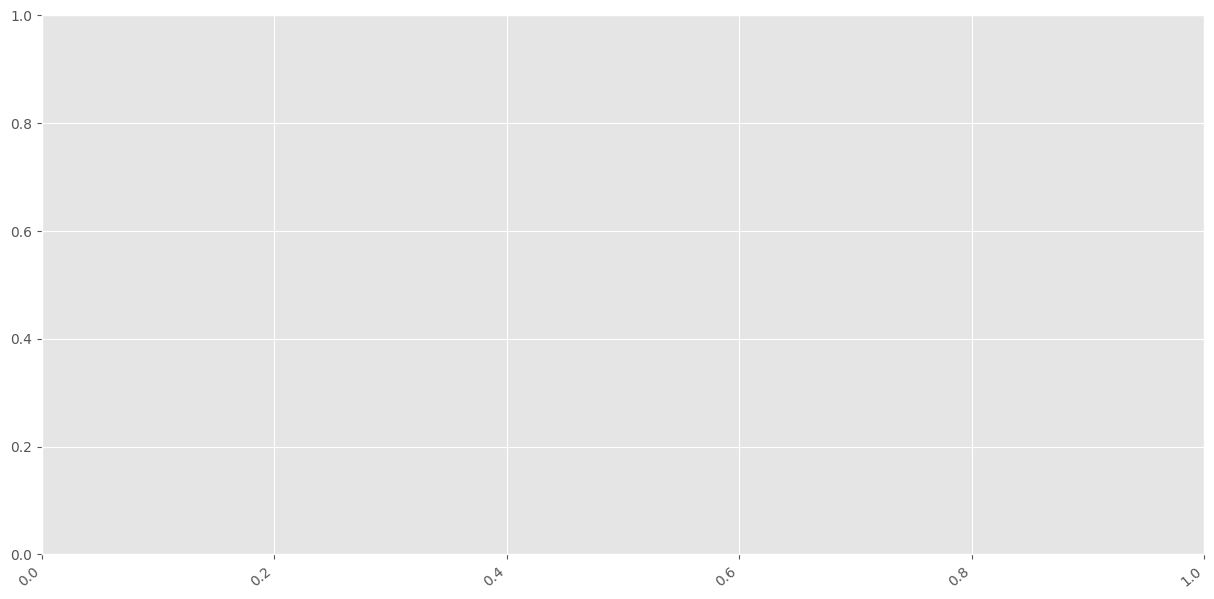

In [50]:
plt.subplots(figsize=(15,7))
ax=sns.boxplot(x='company',y='Price',data=car)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

### Checking relationship of Year with Price

In [30]:
correlation = car['year'].corr(car['Price'])
print("Correlation between Year and Price:", correlation)


Correlation between Year and Price: nan


### Checking relationship of kms_driven with Price

In [31]:
correlation = car['kms_driven'].corr(car['Price'])
print("Correlation between Kms Driven and Price:", correlation)


Correlation between Kms Driven and Price: nan


### Checking relationship of Fuel Type with Price

In [33]:
avg_price_fuel = car.groupby('fuel_type')['Price'].mean().sort_values(ascending=False)
print(avg_price_fuel)


Series([], Name: Price, dtype: float64)


### Relationship of Price with FuelType, Year and Company mixed

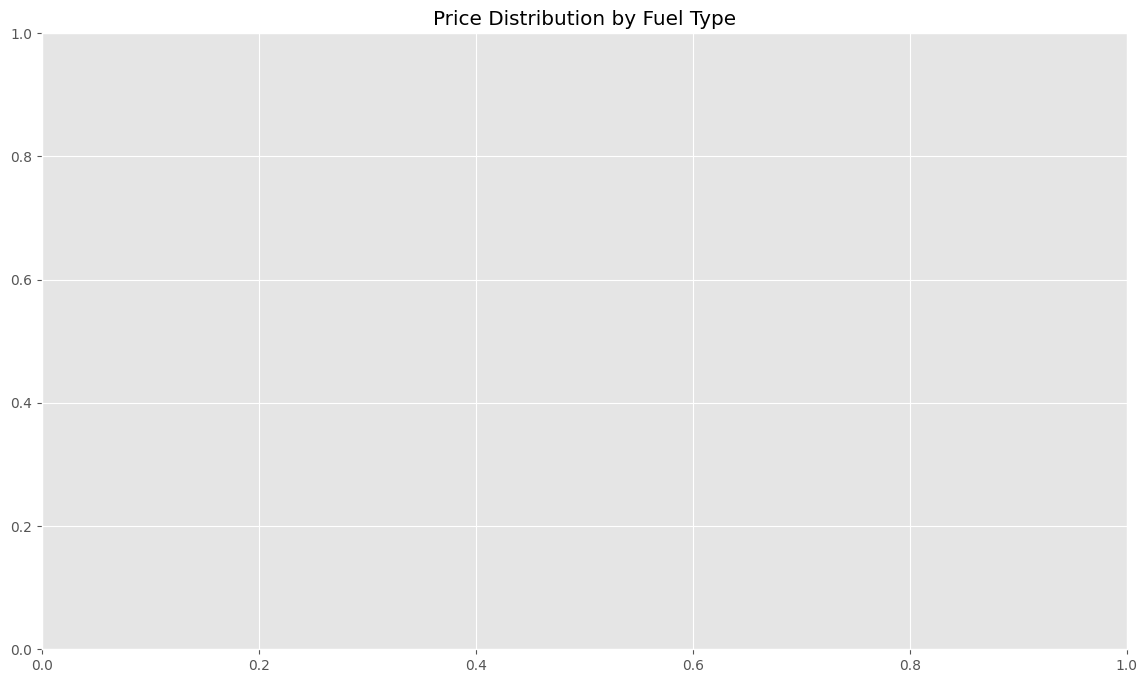

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
sns.boxplot(x="fuel_type", y="Price", data=car)
plt.title("Price Distribution by Fuel Type")
plt.show()


### Extracting Training Data

In [36]:
X=car[['name','company','year','kms_driven','fuel_type']]
y=car['Price']

In [46]:
X = ['year', 'kms_driven', 'fuel_type', 'name']

In [38]:
y.shape

(0,)

### Applying Train Test Split

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features & Target
X = car[['year', 'kms_driven', 'fuel_type', 'name']].copy()
y = car['Price']

# Encoding categorical columns
le_fuel = LabelEncoder()
le_name = LabelEncoder()

X['fuel_type'] = le_fuel.fit_transform(X['fuel_type'])
X['name'] = le_name.fit_transform(X['name'])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Training Data Shape:", X_train.shape)
print("✅ Testing Data Shape:", X_test.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

#### Creating an OneHotEncoder object to contain all the possible categories

In [ ]:
ohe=OneHotEncoder()
ohe.fit(X[['name','company','fuel_type']])

#### Creating a column transformer to transform categorical columns

In [ ]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                                    remainder='passthrough')

#### Linear Regression Model

In [ ]:
lr=LinearRegression()

#### Making a pipeline

In [ ]:
pipe=make_pipeline(column_trans,lr)

#### Fitting the  model

In [ ]:
pipe.fit(X_train,y_train)

In [ ]:
y_pred=pipe.predict(X_test)

#### Checking R2 Score

In [ ]:
r2_score(y_test,y_pred)

#### Finding the model with a random state of TrainTestSplit where the model was found to give almost 0.92 as r2_score

In [ ]:
scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [ ]:
np.argmax(scores)

In [ ]:
scores[np.argmax(scores)]

In [ ]:
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

#### The best model is found at a certain random state

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

In [ ]:
import pickle

In [ ]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [ ]:
pipe.predict(pd.DataFrame(columns=['name','company','year','kms_driven','fuel_type'],data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

In [ ]:
pipe.steps[0][1].transformers[0][1].categories[0]